In [1]:
# Imports

import helpers.helper_functions as hf
import mne
import os.path as op
from mne.channels import combine_channels
import pandas as pd
from mne.beamformer import make_lcmv, apply_lcmv_epochs
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert
import helpers.test_circ_plot as circ_plot
import gc
import helpers.stc_helper as stc_helper
import time
from pycircstat2.hypothesis import rayleigh_test
from mne.stats import permutation_t_test
from mne.stats import fdr_correction


ss = hf.settings_dict()

In [2]:
results_dir = Path(ss["results_dir"])
alpha     = 0.05    # significance threshold

  Significant voxels: 4 / 3031
  Brain activation percentage: 0.13196964698119432%
    Reading a source space...
    [done]
    1 source spaces read


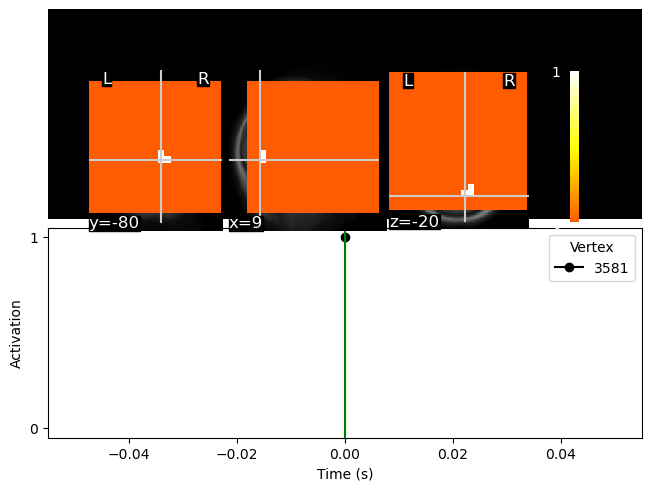

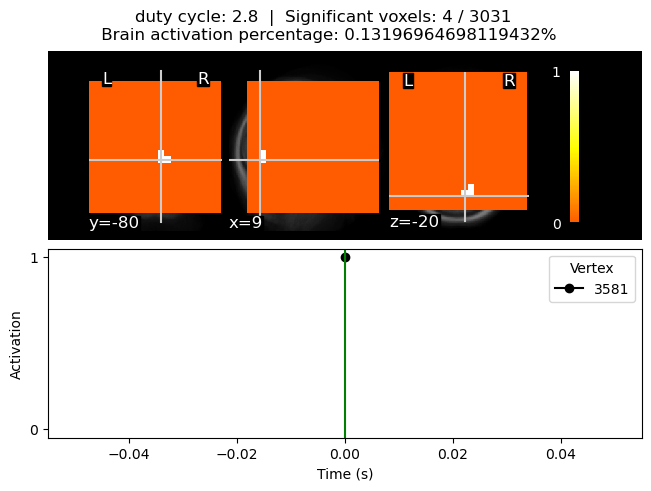

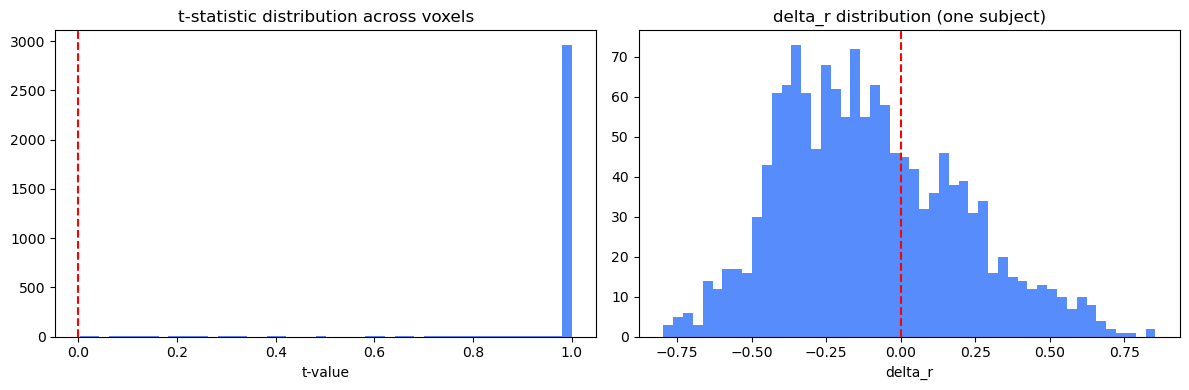

t-stat max : 1.0000
t-stat mean: 0.9913
p-val min  : 0.0029
  Significant voxels: 0 / 3031
  Brain activation percentage: 0.0%
    Reading a source space...
    [done]
    1 source spaces read


/tmp/ipykernel_88736/3947237254.py:24: RuntimeWarning: All data were zero
  brain = sig_stc.plot(


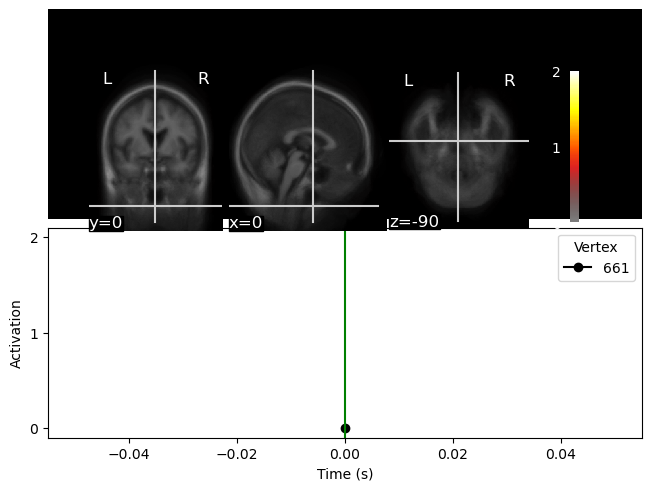

/tmp/ipykernel_88736/3947237254.py:32: RuntimeWarning: All data were zero
  brain = mne.viz.plot_volume_source_estimates(


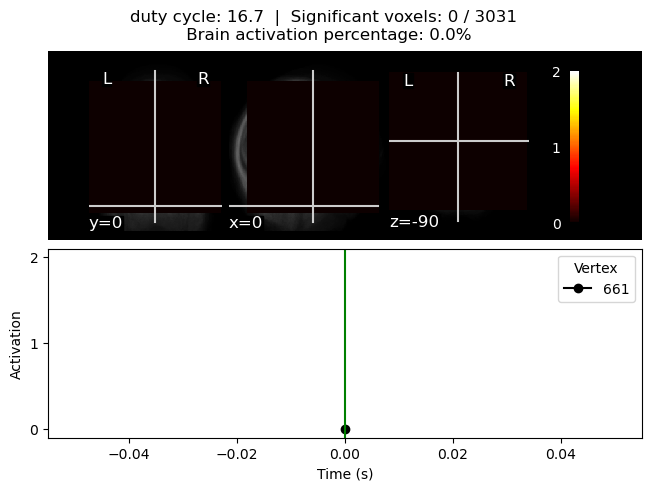

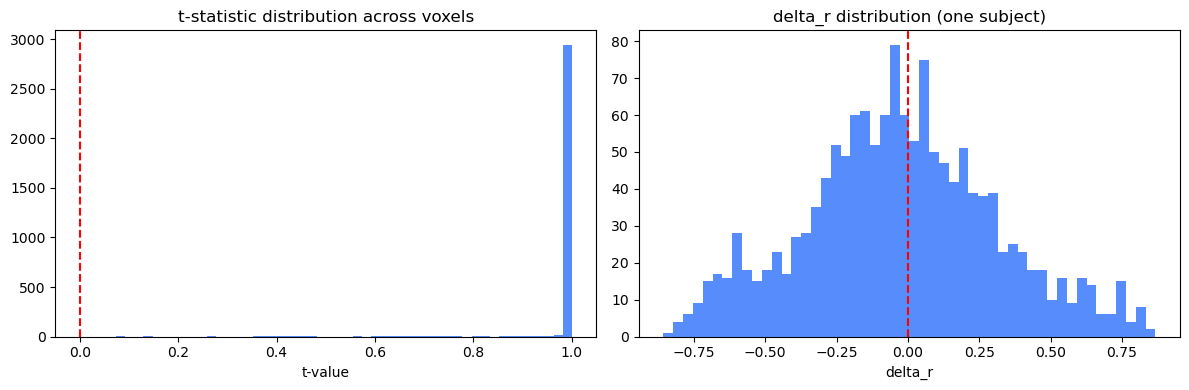

t-stat max : 1.0000
t-stat mean: 0.9933
p-val min  : 0.0737
  Significant voxels: 0 / 3031
  Brain activation percentage: 0.0%
    Reading a source space...
    [done]
    1 source spaces read


/tmp/ipykernel_88736/3947237254.py:24: RuntimeWarning: All data were zero
  brain = sig_stc.plot(


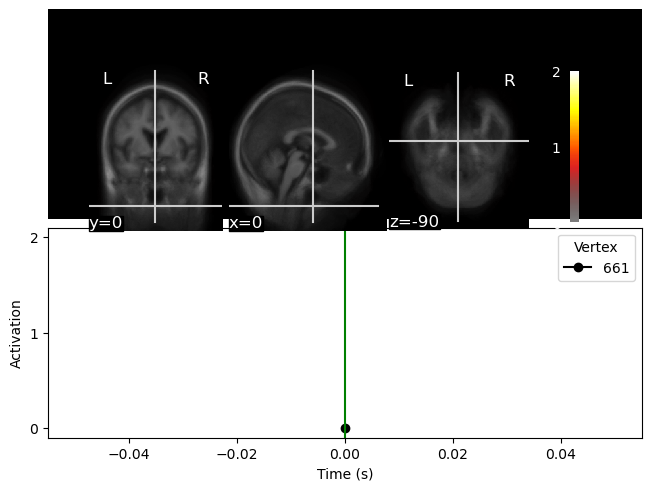

/tmp/ipykernel_88736/3947237254.py:32: RuntimeWarning: All data were zero
  brain = mne.viz.plot_volume_source_estimates(


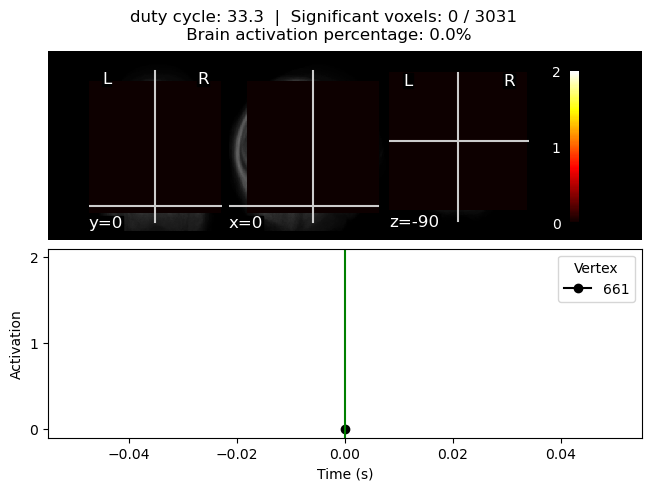

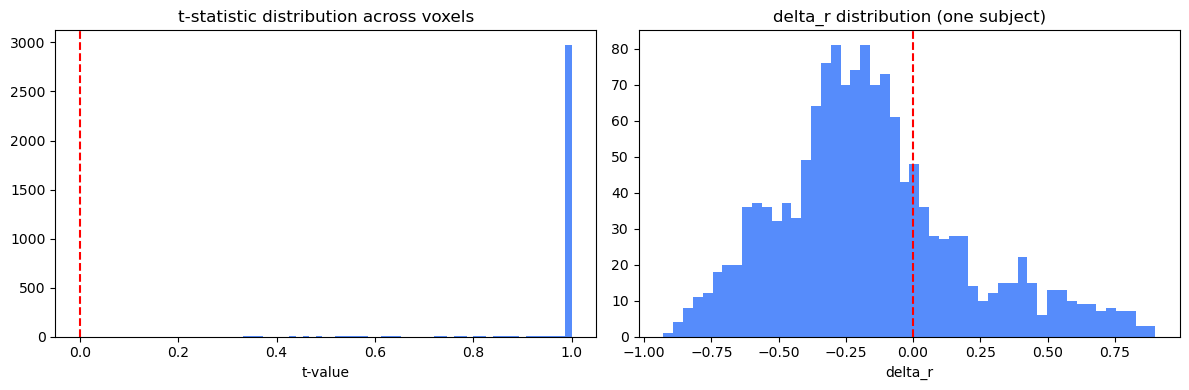

t-stat max : 1.0000
t-stat mean: 0.9954
p-val min  : 0.3325
  Significant voxels: 0 / 3031
  Brain activation percentage: 0.0%
    Reading a source space...
    [done]
    1 source spaces read


/tmp/ipykernel_88736/3947237254.py:24: RuntimeWarning: All data were zero
  brain = sig_stc.plot(


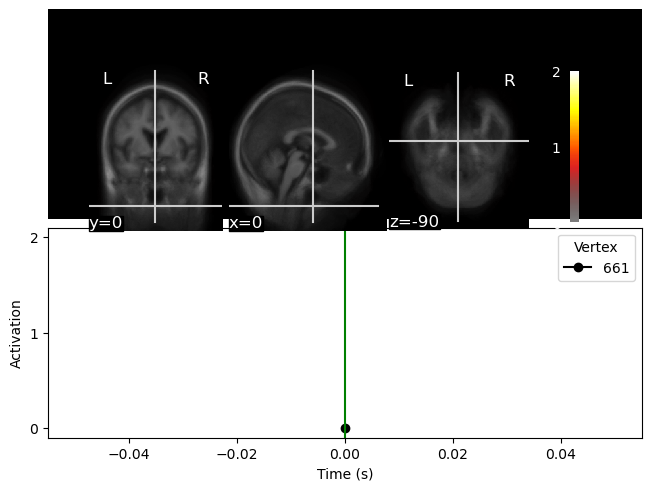

/tmp/ipykernel_88736/3947237254.py:32: RuntimeWarning: All data were zero
  brain = mne.viz.plot_volume_source_estimates(


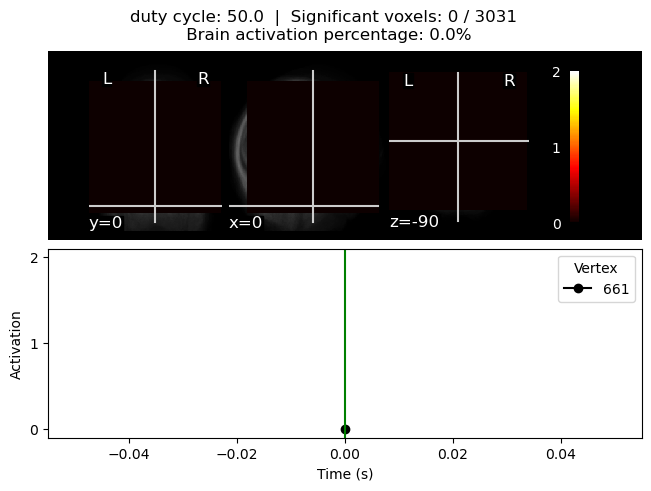

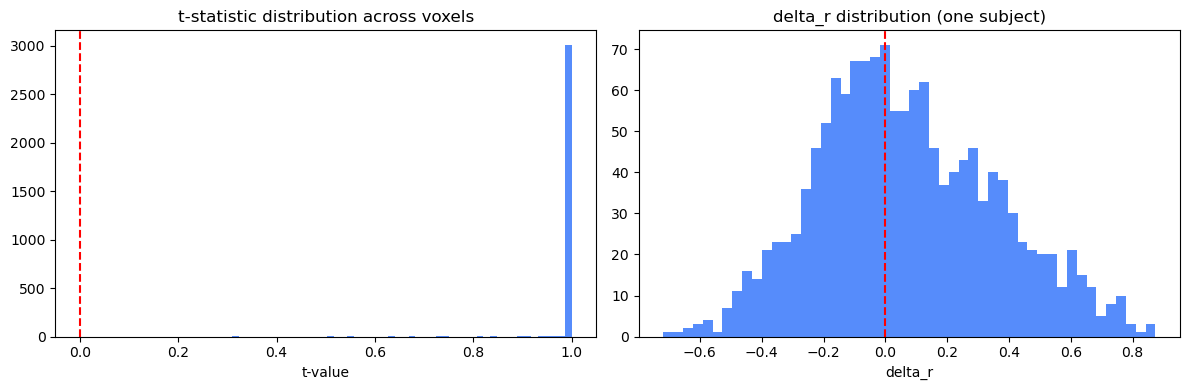

t-stat max : 1.0000
t-stat mean: 0.9987
p-val min  : 0.3091
  Significant voxels: 1 / 3031
  Brain activation percentage: 0.03299241174529858%
    Reading a source space...
    [done]
    1 source spaces read


/tmp/ipykernel_88736/3947237254.py:24: RuntimeWarning: All data were zero
  brain = sig_stc.plot(


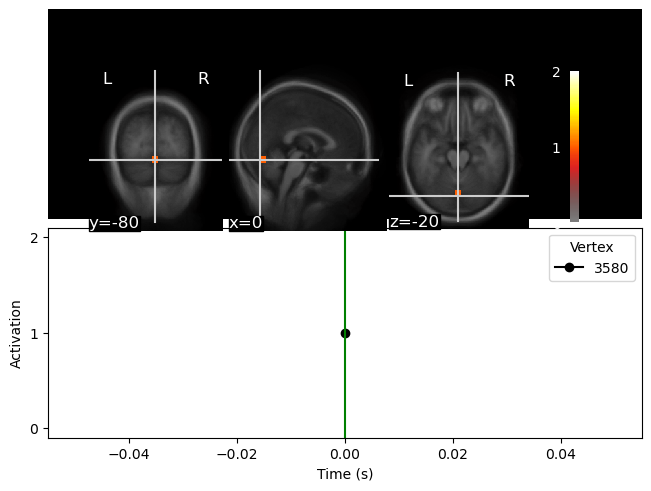

/tmp/ipykernel_88736/3947237254.py:32: RuntimeWarning: All data were zero
  brain = mne.viz.plot_volume_source_estimates(


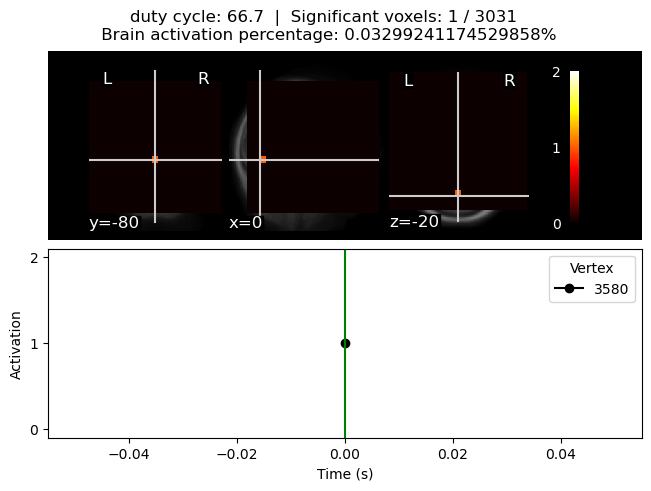

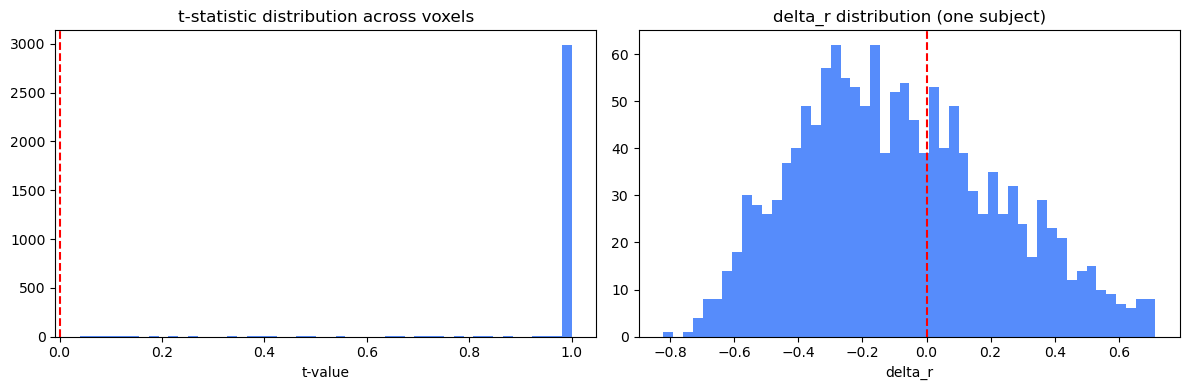

t-stat max : 1.0000
t-stat mean: 0.9940
p-val min  : 0.0396
  Significant voxels: 0 / 3031
  Brain activation percentage: 0.0%
    Reading a source space...
    [done]
    1 source spaces read


/tmp/ipykernel_88736/3947237254.py:24: RuntimeWarning: All data were zero
  brain = sig_stc.plot(


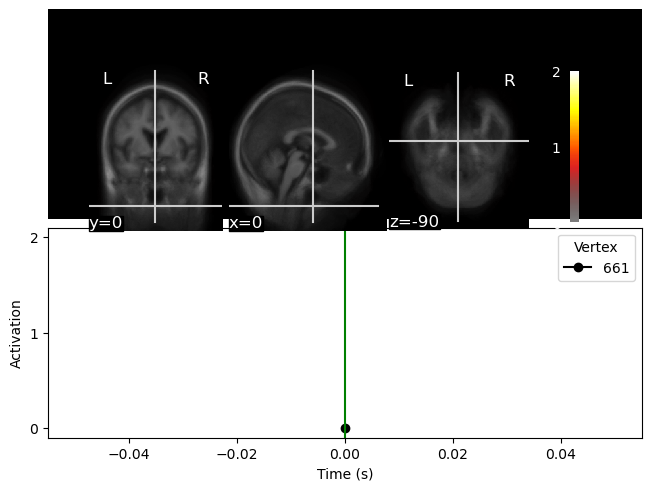

/tmp/ipykernel_88736/3947237254.py:32: RuntimeWarning: All data were zero
  brain = mne.viz.plot_volume_source_estimates(


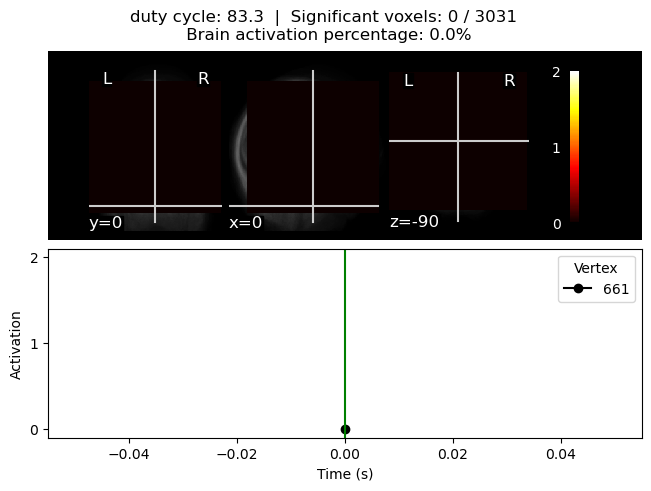

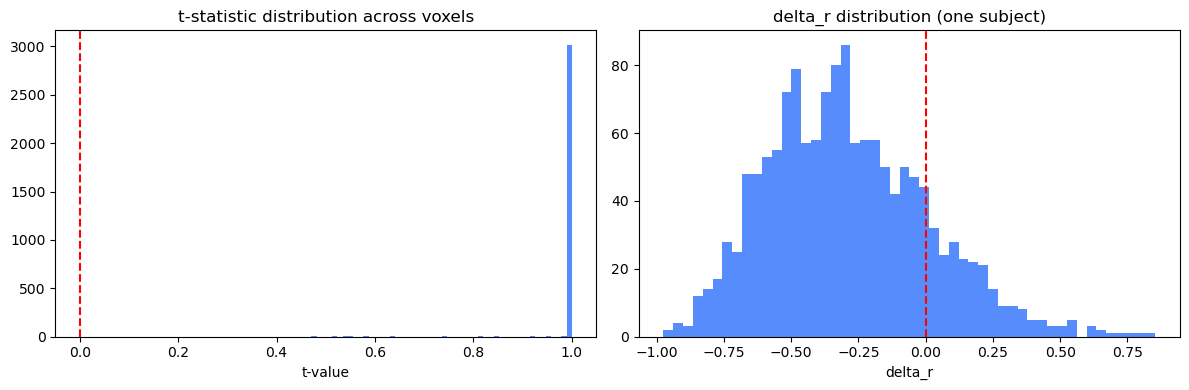

t-stat max : 1.0000
t-stat mean: 0.9988
p-val min  : 0.4707
  Significant voxels: 0 / 3031
  Brain activation percentage: 0.0%
    Reading a source space...
    [done]
    1 source spaces read


/tmp/ipykernel_88736/3947237254.py:24: RuntimeWarning: All data were zero
  brain = sig_stc.plot(


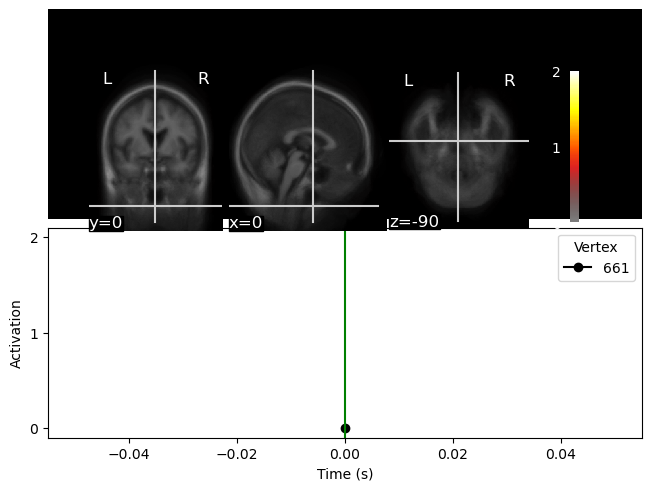

/tmp/ipykernel_88736/3947237254.py:32: RuntimeWarning: All data were zero
  brain = mne.viz.plot_volume_source_estimates(


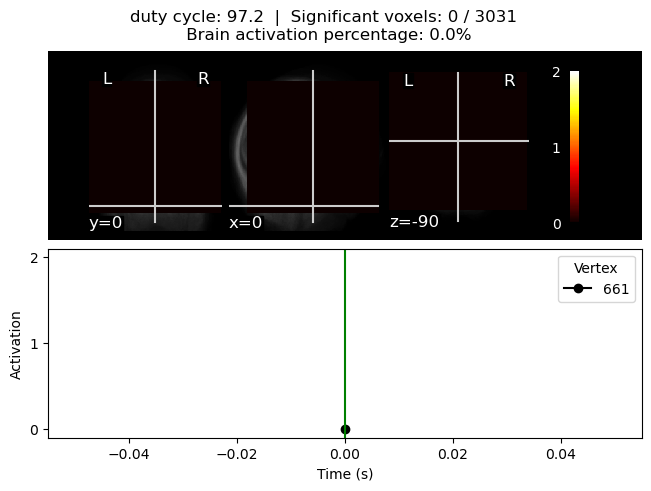

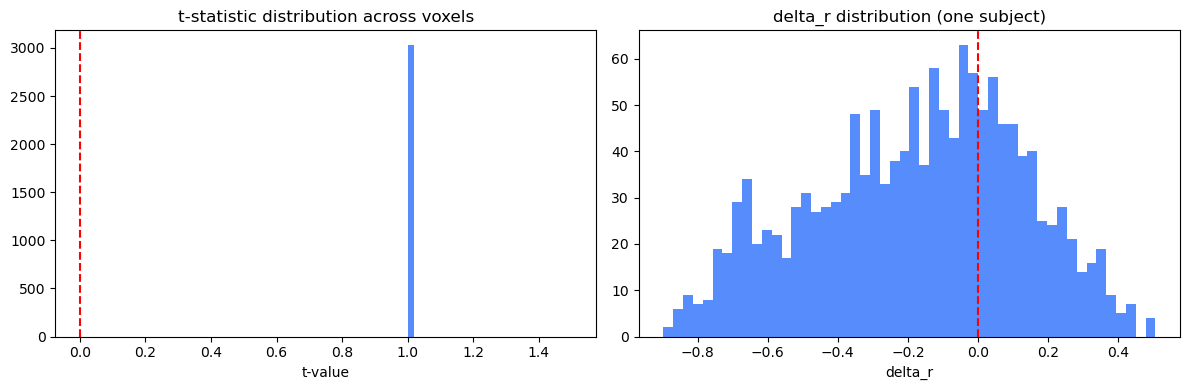

t-stat max : 1.0000
t-stat mean: 1.0000
p-val min  : 1.0000


In [3]:
# loop over each event type
for event_id in ss['event_id_list']:
        event_name = str(event_id)
        duty_cycle = ss['event_name_list'][event_id-1]
        event_dir = results_dir / event_name
        atlas_stc_file = event_dir / f"group-event-{event_name}-puncorr-fsaverage-vol-vl.stc"

        stc = mne.read_source_estimate(atlas_stc_file)

        p_vals  = stc.data[:, 0]

        n_sig = (p_vals < alpha).sum()
        print(f"  Significant voxels: {n_sig} / {len(p_vals)}")
        print(f"  Brain activation percentage: {(n_sig/len(p_vals))*100}%")

        sig_stc = stc.copy()
        sig_stc.data = (p_vals < alpha).astype(float)[:, np.newaxis]


        fsaverage_src_file = Path(ss["fs_subjects_dir"])  / "fsaverage" / "bem" / "fsaverage-vol-10-src.fif"

        fsaverage_src = mne.read_source_spaces(str(fsaverage_src_file))

        brain = sig_stc.plot(
                src=fsaverage_src,
                subject="fsaverage",
                subjects_dir=ss["fs_subjects_dir"],
                mode="stat_map",            # overlays data on anatomical MRI slices
                verbose=False,
            )

        brain = mne.viz.plot_volume_source_estimates(
        stc=sig_stc,
        src=fsaverage_src,
        subject="fsaverage",
        subjects_dir=ss["fs_subjects_dir"],
        mode="stat_map",            # overlays data on anatomical MRI slices
        verbose=False,
        show=False,)

        brain.suptitle(f"duty cycle: {duty_cycle}  |  Significant voxels: {n_sig} / {len(p_vals)} \n Brain activation percentage: {(n_sig/len(p_vals))*100}%")

        # Display the plot
        plt.show()

        t_vals = stc.data[:, 0]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Distribution of t-statistics
        axes[0].hist(t_vals, bins=50)
        axes[0].axvline(0, color='r', linestyle='--')
        axes[0].set_title('t-statistic distribution across voxels')
        axes[0].set_xlabel('t-value')

        # Distribution of delta_r values — load one subject as example
        subject = "0005_3SJ"
        delta_stc = mne.read_source_estimate(str(Path(ss['hilbert_ref_dir']) / subject / event_name / f"{subject}-event-{event_name}-z-vol.stc"))
        axes[1].hist(delta_stc.data[:, 0], bins=50)
        axes[1].axvline(0, color='r', linestyle='--')
        axes[1].set_title('delta_r distribution (one subject)')
        axes[1].set_xlabel('delta_r')

        plt.tight_layout()
        plt.show()

        print(f"t-stat max : {t_vals.max():.4f}")
        print(f"t-stat mean: {t_vals.mean():.4f}")
        print(f"p-val min  : {p_vals.min():.4f}")
